[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ichristov/intermediate-fluid-mechanics/blob/main/Stokes_flow_past_sphere.ipynb)


# LEARNING OBJECTIVE

This notebook demonstrates the solution and visualization of Stokes flow past a sphere. Spherical coordinates are introduced. The problem is worked in **dimensional** form. SymPy is used to perform the vector calculus manipulations. It is also shown how to solve the equidimensional ODE, which arises in finding the Stokes streamfunction, using SymPy. Comparisons to ideal flow past a sphere are made. Ways to check the self-consistency of solutions are discussed. A paradox is observed.

# PRELIMINARIES

[run the next cell to setup Python environment customizations and load packages]

In [1]:
# interactive plots setup
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

# sympy setup
import sympy as sp
sp.init_printing()
from sympy.vector import *

# plotting customizations
from matplotlib import colormaps, animation, rc
from matplotlib import pyplot as plt
size=16
params = {'legend.fontsize': 'large',
#          'figure.figsize': (20,8),
          'axes.labelsize': size,
          'axes.titlesize': size,
          'xtick.labelsize': size*0.875,
          'ytick.labelsize': size*0.875,
          'axes.titlepad': 25}
plt.rcParams.update(params)
%matplotlib inline

# numerics
import numpy as np

# for Colab only: to save plots as files and download them
#from google.colab import files

## Credit

Initial version written by [Ivan C. Christov](http://christov.tmnt-lab.org), Purdue University.

# STOKES FLOW

## Definition

Stokes flows (also known as [creeping flows](https://en.wikipedia.org/wiki/Stokes_flow)) are flows in which fluid inertia is negligible. In other words, when the iNS equations are made dimensionless, we let $Re\to0$ to obtain the Stokes flow equations, which are:
\begin{align*}
  \nabla\cdot\underline{v} &= 0,\\
  \underline{0} &= -\nabla p + \mu \nabla^2 \underline{v},
\end{align*}

By taking the curl of the momentum equation, using the identitis $\nabla^2 \underline{v} = \nabla(\nabla\cdot\underline{v}) - \nabla\times\nabla\times\underline{v}$ and $\nabla\times\nabla p = \underline{0}$, and then using the conservation of mass equation, we obtain:
$$
  \nabla\times\nabla\times\nabla\times\underline{v} = \underline{0}.
$$

## In terms of a streamfunction

In 3 [distinghuished cases](https://en.wikipedia.org/wiki/Stokes_flow#By_stream_function) (2D flow in Cartesian or polar coordinates, 3D axisymmetric flow, and 3D spherically symmetric flow), we can introduce a streamfunction $\psi$ and express the velocity field as:
\begin{alignat*}{3}
  \underline{v} &= \nabla\times \left( \psi(x,y) \underline{e}_z \right)& &\qquad (\text{2D}),\\
  \underline{v} &= \nabla\times \left( \frac{1}{r}\psi(r,z) \underline{e}_\theta \right)& &\qquad (\text{3D cylindrically axisymmetric}),\\
  \underline{v} &= \nabla\times \bigg( \underbrace{\frac{1}{r\sin\theta} \psi(r,\theta)\underline{e}_\phi}_{\underline{B}} \bigg)& &\qquad (\text{3D spherically axisymmetric}).
\end{alignat*}
These definitions are valid for **any incompressible flow** (high, low, or intermediate Reynolds number)!

Thus, the momentum equation of Stokes flow can be written as:
$$
  \nabla\times\nabla\times\nabla\times\nabla\times\underline{B} = \underline{0},
$$
substituting the suitable expression for the _vector potential_ $\underline{B}$ in terms of $\psi$ from above. It turns out, after lengthy algebra, that this last quadruple-curl equation is a _scalar_ equation for the streamfunction:
\begin{align*}
  \nabla^2\nabla^2 \psi &= 0 \qquad (\text{2D}),\\
  E_c^2E_c^2 \psi &= 0 \qquad (\text{3D cylindrically axisymmetric}),\\
  E_s^2E_s^2 \psi &= 0 \qquad (\text{3D spherically axisymmetric}).
\end{align*}
The differential operator $\nabla\times\nabla\times$ ("curl curl") reduces to the Laplacian $\nabla^2$ (defined as "div grad") _only_ in 2D. For the axisymmetric non-Cartesian coordinate systems, "curl curl" becomes some other operator that _looks_ like the Laplacian but it is _not_. We call this new Laplace-like operator $E^2$.

The third case allows us to solve for Stokes flow past a sphere. Let's confirm with [SymPy](https://docs.sympy.org/latest/tutorial/index.html) what the velocity components are expected to be.

In [2]:
# first, setup the 3D spherical coordinate system
c = CoordSys3D('c')
cp = c.create_new('cp', transformation='spherical',
                  vector_names=("r", "th", "ph"),
                  variable_names=("R", "Th", "Ph"))

# print change of coordinates formula for our reference
cp.transformation_to_parent()

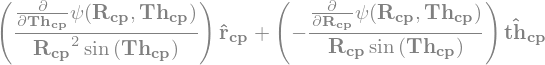

In [3]:
# the velocity = curl (...)
V0, a = sp.symbols('V0, a')
psi = sp.Function('psi')
Bvec = psi(cp.R,  cp.Th) * 1/(cp.R*sp.sin(cp.Th)) * cp.ph
vel = curl(Bvec)
vel

## Definition of the spherical coordinate system

We use the _physics convention_ for [spherical coordinates](https://en.wikipedia.org/wiki/Spherical_coordinate_system) such that
\begin{align*}
    x &= r \sin\theta \, \cos\phi, \\
    y &= r \sin\theta \, \sin\phi, \\
    z &= r \cos\theta. \\
\end{align*}

The [unit vectors transform](https://en.wikipedia.org/wiki/Spherical_coordinate_system#Integration_and_differentiation_in_spherical_coordinates) (needed to map spherical to Cartesian velocities below) as:
\begin{align*}
    \underline{e}_r &= \sin \theta \cos \phi \, \underline{e}_{x} +
    \sin \theta \sin \phi \,\underline{e}_{y} + \cos \theta \,\underline{e}_{z}, \\
    \underline{e}_\theta &= \cos \theta \cos \phi \,\underline{e}_{x} +
    \cos \theta \sin \phi \,\underline{e}_{y} - \sin \theta \,\underline{e}_{z}, \\
    \underline{e}_\phi &= - \sin \phi \,\underline{e}_{x} +
    \cos \phi \,\underline{e}_{y},
\end{align*}
and, [vice versa](https://en.wikipedia.org/wiki/Del_in_cylindrical_and_spherical_coordinates#Unit_vector_conversions) (needed to map Cartesian to spherical velocities below),
\begin{align*}
    \underline{e}_x &= \sin\theta\cos\phi \,\underline{e}_r + \cos\theta\cos\phi \,\underline{e}_\theta -\sin\phi \,\underline{e}_\phi,\\
    \underline{e}_y &= \sin\theta\sin\phi \,\underline{e}_r + \cos\theta\sin\phi \,\underline{e}_\theta + \cos\phi \,\underline{e}_\phi, \\
    \underline{e}_z &= \cos\theta\,\underline{e}_r -\sin\theta \,\underline{e}_\theta.
\end{align*}

Observe that the $\phi = 0$ plane is the $(x,z)$ plane.

schematic of the spherical coordinate system

[Image adapted from [Wikipedia](https://en.wikipedia.org/wiki/Spherical_coordinate_system#/media/File:Kugelkoord-lokb-e.svg).]

## Past a sphere

Consider a sphere of radius $a$ centered at the origin $O$.

### The incoming uniform flow

In the context of spherical symmetry, all quantities are independent of $\phi$. This assumption means that we can consider flow coming up towards the sphere in the $+z$ direction (observe this is the only way that this uniform flow can be independent of $\phi$):
$$
    \underline{v}_0 = V_0 \underline{e}_z = V_0 \cdot ( \cos\theta \,\underline{e}_r - \sin\theta \,\underline{e}_\theta ).
$$
using the vector transformation above.


Away from the sphere, as $r\to\infty$, the flow must eventually become the undisturbed $\underline{v}_0$ flow again. In other words:
\begin{alignat*}{3}
    v_r(r,\theta)      &\to +V_0 \cos\theta,& &\qquad r\to\infty,\\
    v_\theta(r,\theta) &\to -V_0 \sin\theta,& &\qquad r\to\infty.
\end{alignat*}

### Inferring the form of the streamfunction (separation of variables)

From the above, we also know that
$$
     v_r(r,\theta) = \frac{1}{r^2\sin\theta} \frac{\partial \psi}{\partial \theta}.
$$
Thus, we must have that
$$
    \frac{1}{r^2\sin\theta} \frac{\partial \psi}{\partial \theta} \to U_0 \cos\theta,\qquad r\to\infty,
$$
or, rearranging and integrating with respect to $\theta$,
$$
    \psi(r,\theta) \to \frac{U_0 r^2}{2} \sin^2\theta,\qquad r\to\infty.
$$
From this we infer that the boundary conditions **require** the streamfunction to have the form
$$
    \psi(r,\theta) = F(r)\sin^2\theta,\qquad F(r) \sim  \frac{U_0 r^2}{2} \quad\text{as}\quad r\to\infty.
$$

### Boundary conditions

On the surface of the sphere, $r=a$, the flow does not slip, thus:
\begin{align*}
    v_r(a,\theta) &= 0,\\
    v_\theta(a,\theta) &= 0.
\end{align*}
In terms of the streamfunction:
\begin{align*}
    \frac{1}{a^2\sin\theta} \left. \frac{\partial \psi}{\partial \theta}\right|_{r=a} &= 0,\\
    \frac{-1}{a\sin\theta} \left. \frac{\partial \psi}{\partial r} \right|_{r=a} &= 0.
\end{align*}
Using the form of the streamfunction deduced above:
\begin{align*}
    V_0 F(a) \cos\theta &= 0,\\
    V_0 F'(a) \sin\theta &= 0.
\end{align*}
The BCs apply for all $\theta$, so:
\begin{align*}
    F(a) &= 0,\\
    F'(a) &= 0.
\end{align*}

### The ODE for $F(r)$

We can plug the latter form into the definition of the velocity and let SymPy crunch the vector calculus of simplifying $\nabla\times\nabla\times\nabla\times\nabla\times\underline{B}$.

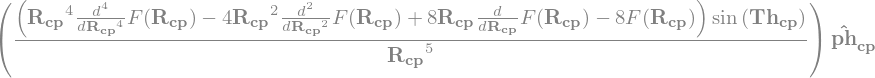

In [4]:
F = sp.Function('F')
Bvec = (F(cp.R) * sp.sin(cp.Th)**2) * 1/(cp.R*sp.sin(cp.Th)) * cp.ph
sp.simplify(curl(curl(curl(curl(Bvec)))))

Expression is a vector, as should be expected, and for this vector to be $\underline{0}$, we set the component $=0$. Since the governing equation must be valid for _all_ $\theta$ and $r>0$, we can multiply by $r^5$ and divide by $\sin\theta$ without worry.

The ODE for $F(r)$ is thus:
$$
    r^4 F''''(r) - 4 r^2 F''(r) + 8 r F'(r) - 8 F(r) = 0.
$$

This linear, variable coefficient, fourth-order ODE is known as the _equidimensional_ (or [Cauchy&ndash;Euler](https://en.wikipedia.org/wiki/Cauchy%E2%80%93Euler_equation)) ODE. Versions of this ODE show up in solving for both axisymmetric Stokes and ideal flows.

We may seek linearly independent solutions of the form $r^n$, or obtain a general solution of the ODE using SymPy.

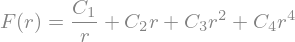

In [5]:
r, a, V0 = sp.symbols('r, a, V0')
soln = sp.dsolve(r**4*sp.Derivative(F(r), r, r, r, r)
                 - 4*r**2*sp.Derivative(F(r), r, r)
                 + 8*r*sp.Derivative(F(r), r)
                 - 8*F(r), F(r))
soln

We also apply BCs at fixed $r$ values, $F(a) = F'(a)=0$ immediately:

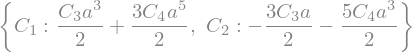

In [6]:
C1, C2, C3, C4 = sp.symbols('C1, C2, C3, C4')
constants = sp.solve([soln.rhs.subs({r: a}) - 0, 
                      soln.rhs.diff(r).subs({r: a}) - 0], 
                      {C1, C2})
constants

 and simplify:

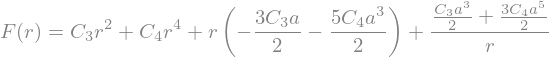

In [7]:
soln2 = soln.subs(constants)
soln2

To apply the asymptotic BC $F(r) \sim \tfrac{U_0}{2}r^2$ takes some extra work. We can understand this condition as follows:
$$
  \lim_{r \to \infty} \frac{F(r)}{\tfrac{V_0}{2}r^2} = 1.
$$

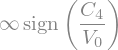

In [8]:
sp.limit(soln2.rhs/(V0/2*r**2), r, sp.oo)

This limit does not exist _unless_ we take $C_4 =0$:

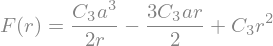

In [9]:
soln3 = soln2.subs(constants).subs({C4: 0})
soln3

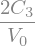

In [10]:
sp.limit(soln3.rhs/(V0/2*r**2), r, sp.oo)

Great, now the limit is finite. But, to satisfy the asymptotic BC as stated above, we must take $C_3 = V_0/2$ to make the limit $1$.

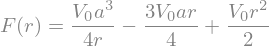

In [11]:
soln4 = soln3.subs(constants).subs({C3: V0/2})
soln4

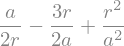

In [12]:
sp.simplify(soln4.rhs/(V0*a**2/2))

Thus, finally, the streamfunction solution for Stokes flow, of incoming uniform velocity $V_0$, past a sphere of radius $a$, is
$$
    \psi(r,\theta) = \frac{V_0 a^2}{2} \left[\frac{1}{2}\left(\frac{r}{a}\right)^{-1} - \frac{3}{2} \left(\frac{r}{a}\right) + \left(\frac{r}{a}\right)^2 \right]\sin^2\theta.
$$

### Consistency check

We can check again with SymPy that this is a proper solution.

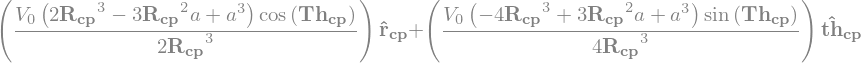

In [13]:
# the velocity = curl (...)
psi = sp.Rational(1, 2)*V0*a**2*((cp.R/a)**2 + sp.Rational(1, 2)/(cp.R/a)
                                 - sp.Rational(3, 2)*(cp.R/a))*sp.sin(cp.Th)**2
# sp.Rational(1,2) is just 1/2 but as a fraction, not as a decimal
# and this makes the answer look nicer
Bvec = psi * 1/(cp.R*sp.sin(cp.Th)) * cp.ph
vel = curl(Bvec)
sp.simplify(vel)

In [14]:
# check conservation of mass
divergence(vel)

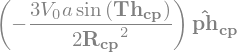

In [15]:
# the vorticity = curl vel
omega = curl(vel)
sp.simplify(omega)

In [16]:
# curl curl of the vorticity must vanish in Stokes flow
sp.simplify(curl(curl(omega)))

### Drag force on the sphere

The stress on a surface computed as usual from the Cauchy stress, $\underline{\underline{T}} = -p\underline{\underline{I}} + \underline{\underline{\tau}}$, where $\underline{\underline{\tau}} = \mu(\nabla\underline{v} + \nabla\underline{v}^\top)$, by left-multiplying it by the normal vector $\underline{n}$ to the surface under consideration. For the sphere, $\underline{n}=\underline{e}_r$.

Of course, $\underline{e}_r\cdot\underline{\underline{T}}$ is a _vector_, representing the net fluid force on any point on the sphere's surface. We would like to know _specifically_ the component along the flow direction, which is what we call the "drag".

So, we need to use the transformation of unit vectors again, and calculate
\begin{align*}
    \underline{e}_r\cdot\underline{\underline{T}}\cdot\underline{e}_z &= \underline{e}_r\cdot\underline{\underline{T}}\cdot\underline{e}_r \cos\theta - \underline{e}_r\cdot\underline{\underline{T}}\cdot\underline{e}_\theta \sin\theta\\
    &= (\underbrace{-p + \tau_{rr}}_{T_{rr}}) \cos\theta - (\underbrace{0 + \tau_{r\theta}}_{T_{r\theta}})\sin\theta,
\end{align*}
and integrate it over the surface of the sphere, which is $\{(r,\theta,\phi) \,|\, r=a,\,0\le \theta \le \pi,\,0\le \phi\le 2\pi\}$. Note that [$\theta$ doesn't go to $2\pi$](https://en.wikipedia.org/wiki/Spherical_coordinate_system#Integration_and_differentiation_in_spherical_coordinates) so we don't double count any area! The area element for spherical symmetry at $r=a$ is
$$
    dA = 2\pi a^2 \sin\theta \,d\theta.
$$

#### The pressure

We find the pressure from the Stokes equation, $\nabla p = -\mu\nabla\times\underline{\omega}$. Note that the right-hand side is a vector expressed as the potential of a scalar on the left-hand side. SymPy has a conventient function to find this [scalar potential](https://docs.sympy.org/latest/modules/vector/api/vectorfunctions.html#sympy.vector.scalar_potential).

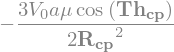

In [17]:
# there seems to be a BUG (!?) though, and an extra r shows up in the denominator,
# so we hack it
mu = sp.Symbol('mu')
StokesRHS = sp.simplify(-mu*curl(omega))

pundograd = scalar_potential(StokesRHS, cp) * cp.R
pundograd

In [18]:
# check that the hack worked by taking its gradient and comparing to Stokes' RHS
sp.simplify(gradient(pundograd) - StokesRHS)

Thus, defined up to an arbitrary constant $p_\infty = \lim_{r\to\infty} p$ setting the gage, is thus

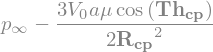

In [19]:
pinf = sp.Symbol(r'p_{\infty}')
p = pinf + pundograd
p

Finally, we need to calculate the integral
\begin{align*}
    &\iint (-p|_{r=a} \cos\theta) \, dA \\
    &= 2\pi a^2 \int_0^\pi (- p|_{r=a} \cos\theta) \sin\theta\,d\theta.
\end{align*}

In [20]:
# don't forget the cos from the evaluation of e_r*T*e_z above
pint = 2*sp.pi*a**2 \
       * sp.integrate((-p.subs({cp.R: a})*sp.cos(cp.Th)) * sp.sin(cp.Th), 
                      (cp.Th, 0, sp.pi))
pint.simplify()

#### The viscous stress on the sphere

Unfortunately, SymPy cannot do gradients of vectors in non-Cartesian coordinates. We have to turn to Table C.3 in the Appendices of Panton (noting the **typo** where $1/r+$ should be $1/r \cdot$, multiplication not addition!):
\begin{align*}
    \tau_{rr} &= 2\mu \frac{\partial v_r}{\partial r},\\
    \tau_{r\theta} &= \mu\left[r \frac{\partial}{\partial r}\left(\frac{v_\theta}{r}\right) + \frac{1}{r}\frac{\partial v_r}{\partial \theta}\right].
\end{align*}


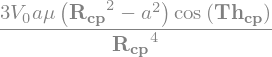

In [21]:
# use dot products (&) with coord vectors to extra v_r, v_th from vel vector computed above
taurr = 2*mu*(vel & cp.r).diff(cp.R)
taurr.simplify()

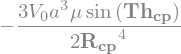

In [22]:
taurth = mu*(cp.R*((vel & cp.th)/cp.R).diff(cp.R) \
             + (vel & cp.r).diff(cp.Th)/cp.R)
taurth.simplify()

Finally, we need to calculate the integral
\begin{align*}
    &\iint (\tau_{rr}|_{r=a} \cos\theta - \tau_{r\theta}|_{r=a} \sin\theta) \, dA \\
    &= 2\pi a^2 \int_0^\pi (\tau_{rr}|_{r=a}\cos\theta - \tau_{r\theta}|_{r=a} \sin\theta) \, \sin\theta\,d\theta.
\end{align*}

In [23]:
# don't forget the cos, -sin from the evaluation of e_r*T*e_z above
tauint = 2*sp.pi*a**2 \
         * sp.integrate((taurr.subs({cp.R: a})*sp.cos(cp.Th)
                         - taurth.subs({cp.R: a})*sp.sin(cp.Th)) * sp.sin(cp.Th),
                         (cp.Th, 0, sp.pi))
tauint.simplify()

Thus:
$$
    F_D = 2\pi \mu a V_0 + 4\pi \mu a V_0 = 6\pi \mu a V_0.
$$

But note that $\tau_{rr}$ did not actually contribute!

In [24]:
sp.integrate((taurr.subs({cp.R: a})*sp.cos(cp.Th)) * sp.sin(cp.Th), 
             (cp.Th, 0, sp.pi))

Robert Millikan [used](https://www.science.org/doi/10.1126/science.32.822.436) Stokes' drag law above to perform his [Nobel Prize](https://www.nobelprize.org/prizes/physics/1923/millikan/facts/) winning research on the charge of the electron. Though his data analysis was not without [controversy](https://link.springer.com/article/10.1007/s00897970102a).

# VISUALIZATION


First, setup an uniform mesh in 3D to use for all plotting. Also define velocity magnitude and radius of sphere here.

In [25]:
velmag = 1
rad = 1

# range
xmax = 3*rad
zmax = 3*rad

# grid
x, z = np.meshgrid(np.linspace(-xmax, xmax, num=100),
                   np.linspace(-zmax, zmax, num=100))

# convert (x,z) to (r,th) for plotting in axisymmetric spherical coordinates
# note: arctan2(x,z) computes arctangent(x/z) taking into account the
# signs of x and z, which is important for these problems.
th = np.arctan2(x, z)
rp = np.sqrt(x**2 + z**2)

## Velocity

Second, visualize the velocity field past the sphere in the $\phi=0$ plane.

In [26]:
# evaluate the velocity components computed above
vr = velmag*np.cos(th)*((1/2)/(rp/rad)**3 - (3/2)/(rp/rad) + 1)
vth = -velmag*np.sin(th)*(- (1/4)/(rp/rad)**3 - (3/4)/(rp/rad) + 1)

# convert the later to Cartesian velocities for plotting
# NOTE: this transformation is NOT the same as for planar polar coords,
# see the expressions at the beginning of the notebook
vx = vr*np.sin(th) + vth*np.cos(th)
vz = vr*np.cos(th) - vth*np.sin(th)

# set all velocity values inside the sphere to nan
# so that they're not plotted...the flow is outside the sphere
vx[np.where(x**2 + z**2 < rad**2)] = np.nan
vz[np.where(x**2 + z**2 < rad**2)] = np.nan

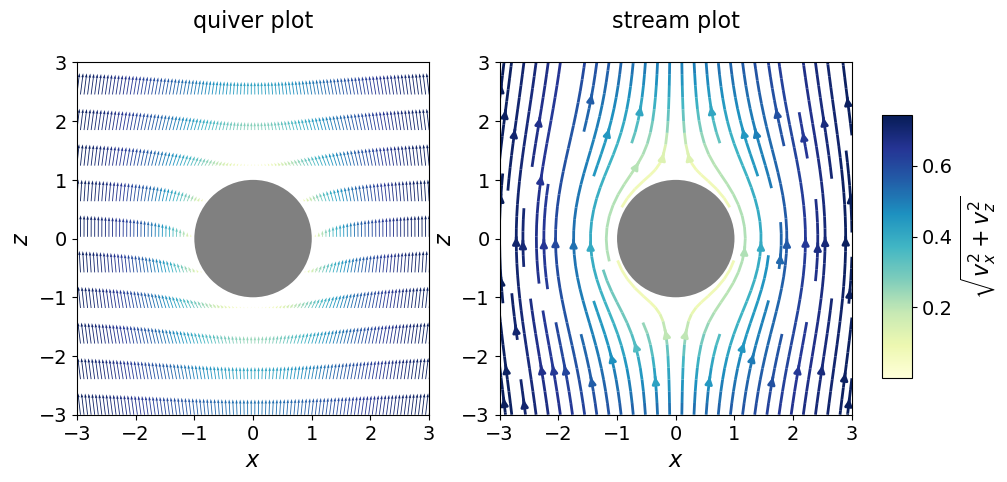

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2)

ax1.set_xlabel('$x$')
ax1.set_ylabel('$z$')
ax1.set_xlim([-xmax, xmax])
ax1.set_ylim([-zmax, zmax])
ax1.set_title('quiver plot')
ax1.set_aspect('equal')

# plot velocity in the phi=0 plane, skip some points for clarity
skip = 10
ax1.quiver(x[::skip], z[::skip], vx[::skip], vz[::skip],
           np.sqrt(vx[::skip]**2+vz[::skip]**2), cmap='YlGnBu',
           scale_units='xy', scale=2)
# show the sphere
ax1.add_patch(plt.Circle((0, 0), radius=rad, facecolor='gray', zorder=10))

ax2.set_xlabel('$x$')
ax2.set_ylabel('$z$')
ax2.set_xlim([-xmax, xmax])
ax2.set_ylim([-zmax, zmax])
ax2.set_title('stream plot')
ax2.set_aspect('equal')

strm = ax2.streamplot(x, z, vx, vz,
                      color=np.sqrt(vx**2+vz**2),
                      linewidth=2, cmap='YlGnBu')
# show the sphere
ax2.add_patch(plt.Circle((0, 0), radius=rad, facecolor='gray', zorder=10))

# make the colorabar look nice ...
pos = ax2.get_position()
pad, width = 0.03, 0.03
ax3 = fig.add_axes([pos.xmax + pad, pos.ymin + 2*pad,
                   width, 0.7*(pos.ymax-pos.ymin)])
fig.colorbar(strm.lines, cax=ax3, label=r'$\sqrt{v_x^2+v_z^2}$')

fig.set_size_inches(10, 8)

## Streamlines

First, visualize the streamlines past the sphere in the $\phi=0$, or $(x,z)$, plane ($\phi$ here is the "other" angle of the spherical coordinate system, _not_ the velocity potential!).

In [28]:
# compute the streamfunction
psi_v = 1/2*velmag*rad**2 \
        * np.sin(th)**2*((rp/rad)**2 + 1/2/(rp/rad) - 3/2*(rp/rad))

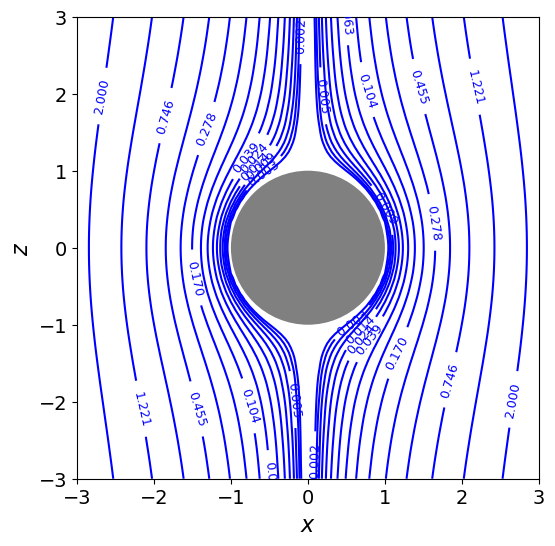

In [29]:
fig, ax = plt.subplots()
ax.set_xlabel('$x$')
ax.set_ylabel('$z$')
ax.set_aspect('equal')

# plot 15 streamlines as contours of the function psi
# space them out using logspace to get more values closer to 0
levels = np.logspace(-3, 0, 15, endpoint=True)*2
cspsi = ax.contour(x, z, psi_v, levels, colors='b')

# label the contours with their values
ax.clabel(cspsi, inline=1, fontsize=9)

# show the sphere
c = plt.Circle((0, 0), radius=rad, facecolor='gray', zorder=10)
ax.add_patch(c)

# make the output figure a bit larger
fig.set_size_inches(8, 6)
#  fig.show()

### Comparison to the photograph from _An Album of Fluid Motion_

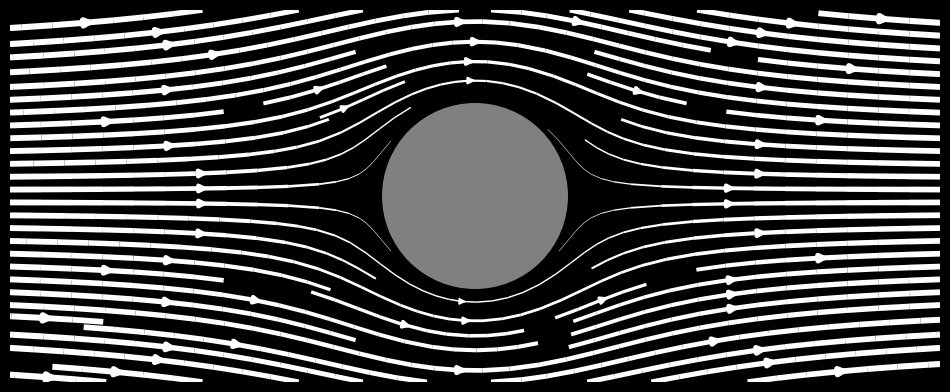

In [30]:
# flip x,z to make the plot horizontal
newzmax = 5*rad
newxmax = 2*rad
newz, newx = np.meshgrid(np.linspace(-newzmax, newzmax, num=100),
                         np.linspace(-newxmax, newxmax, num=100))

newth = np.arctan2(newx, newz)
newrp = np.sqrt(newx**2 + newz**2)

newvr = 2*np.cos(newth)*((1/2)/(newrp/rad)**3 - (3/2)/(newrp/rad) + 1)
newvth = -2*np.sin(newth)*(- (1/4)/(newrp/rad)**3 - (3/4)/(newrp/rad) + 1)

newvx = newvr*np.sin(newth) + newvth*np.cos(newth)
newvz = newvr*np.cos(newth) - newvth*np.sin(newth)

newvx[np.where(newx**2 + newz**2 < rad**2)] = np.nan
newvz[np.where(newx**2 + newz**2 < rad**2)] = np.nan

plt.style.use('dark_background')  # !
fig, ax = plt.subplots()

# white streamlines with variable width
speed = np.sqrt(newvx**2 + newvz**2)
mylw = 3*speed
strm = ax.streamplot(newz, newx, newvz, newvx, linewidth=mylw, color='white')
ax.add_patch(plt.Circle((0, 0), radius=rad, facecolor='gray', zorder=10))

ax.set_xlim([-newzmax, newzmax])
ax.set_ylim([-newxmax, newxmax])
ax.set_aspect('equal')
ax.axis("off")
fig.set_size_inches(12, 10)
plt.style.use('default')         # !

You can compare the last plot to the experimental visualization shown in [Van Dyke's _An Album of Fluid Motion_](https://drive.google.com/file/d/0B5UvitjuXx-bVWdoMFQxUXlZek0/view?resourcekey=0-6l7d0NYe7FY8muhx8pCL8A).

experimental visualization of Stokes flow past a sphere

# COMPARISON TO IDEAL FLOW

## Ideal flow past a sphere

### Solution

Ideal (inviscid) flow past a 3D sphere can also be derived in much the same way as Stokes (purely viscous) flow past a 3D sphere. The main difference is that, in for ideal flow, $E_s^2\psi =0$ (arising from $\nabla\times\nabla\times\underline{B}$), _instead of_ $E_s^2E_s^2\psi=0$ (arising from $\nabla\times\nabla\times\nabla\times\nabla\times\underline{B}$).

(Note that the velocity potential $\phi$ still satisfies $\nabla^2\phi=0$ with the Laplacian in spherical coordinates; see Panton's Section 19.1.)

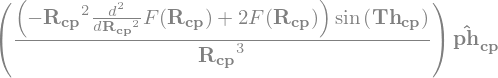

In [31]:
Bvec = (F(cp.R) * sp.sin(cp.Th)**2) * 1/(cp.R*sp.sin(cp.Th)) * cp.ph
sp.simplify(curl(curl(Bvec)))

So, the ODE is now
$$
    -r^2 F''(r) + 2 F(r) = 0,
$$
subject to the far-field
$$
    \lim_{r \to \infty} \frac{F(r)}{\tfrac{V_0}{2}r^2} = 1
$$
and no-penetration
$$
    F(a) = 0
$$
conditions.

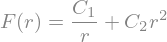

In [32]:
soln = sp.dsolve(-r**2*sp.Derivative(F(r), r, r)
                 + 2*F(r), F(r))
soln

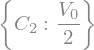

In [33]:
c2sol = sp.solve(sp.Eq(sp.limit(soln.rhs/(V0/2*r**2), r, sp.oo), 1))[0]
c2sol

In [34]:
c1sol = sp.solve(soln.rhs.subs({r: a}))[0]
c1sol

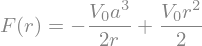

In [35]:
soln2 = soln.subs(c1sol).subs(c2sol)
soln2

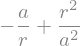

In [36]:
sp.simplify(soln2.rhs/(V0*a**2/2))

The solution is thus (see also Panton's Section 19.8):
$$ \psi(r,\theta) = \frac{V_0 a^2}{2} \left[ - \left(\frac{r}{a}\right)^{-1}  + \left(\frac{r}{a}\right)^2 \right] \sin^2\theta .$$

It does look similar to the Stokes flow solution but the $r$-dependent term in the brackets is different.

The no slip condition $F'(a)=0$ is not satisfied:

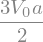

In [37]:
soln2.rhs.diff(r).subs({r: a})

### Consistency check

Again, we can use SymPy to check if this solution satisfies the governing equations.

In [38]:
# first, setup the 3D spherical coordinate system
c = CoordSys3D('c')
cp = c.create_new('cp', transformation='spherical',
                  vector_names=("r", "th", "ph"),
                  variable_names=("R", "Th", "Ph"))

# print change of coordinates formula for our reference
cp.transformation_to_parent()

As before, the velocity field is defined as
$$
  \underline{v} = \nabla\times \bigg( \underbrace{\frac{1}{r\sin\theta} \psi(r,\theta) \underline{e}_\phi}_{\underline{B}} \bigg)
$$
for spherically symmetric flow.

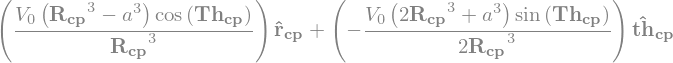

In [39]:
# the velocity = curl (...)
V0, a = sp.symbols('V0 a')
psi = sp.Rational(1, 2)*V0*a**2*((cp.R/a)**2 - 1/(cp.R/a))*sp.sin(cp.Th)**2
Bvec = psi * 1/(cp.R*sp.sin(cp.Th)) * cp.ph
vel_i = curl(Bvec)
sp.simplify(vel_i)

We may check conservation of mass ($\nabla\cdot\underline{v}=0$):

In [40]:
divergence(vel_i)

We may check that this ideal flow is irrotational ($\underline{\omega} = \underline{0}$):

In [41]:
# the vorticity = curl vel
omega_i = curl(vel_i)
sp.simplify(omega_i)

To check whether $E_s^2\psi=0$ without defining $E_s^2$ actually becomes trivial for the case of ideal flow. The relation $E_s^2\psi=0$ arises from the irrotational assumption requiring that $\underline{\omega} = \nabla\times\underline{v} = \nabla\times\nabla\times\underline{B} = \underline{0}$ for the $\underline{B}$ vector defined above. So, we have shown this to be true already.

It actually turns out that even $\nabla\cdot\underline{B}=0$, as discussed in Panton's Section 12.5.

In [42]:
divergence(Bvec)

## Velocity

In [43]:
# evaluate the velocity components computed above
vr = velmag*np.cos(th)*(-1/(rp/rad)**3 + 1)
vth = -velmag*np.sin(th)*((1/2)/(rp/rad)**3 + 1)

# convert the later to Cartesian velocities for plotting
# NOTE: this transformation is NOT the same as for planar polar coords,
# see the expressions at the beginning of the notebook
vx = vr*np.sin(th) + vth*np.cos(th)
vz = vr*np.cos(th) - vth*np.sin(th)

# set all velocity values inside the sphere to nan
# so that they're not plotted...the flow is outside the sphere
vx[np.where(x**2 + z**2 < rad**2)] = np.nan
vz[np.where(x**2 + z**2 < rad**2)] = np.nan

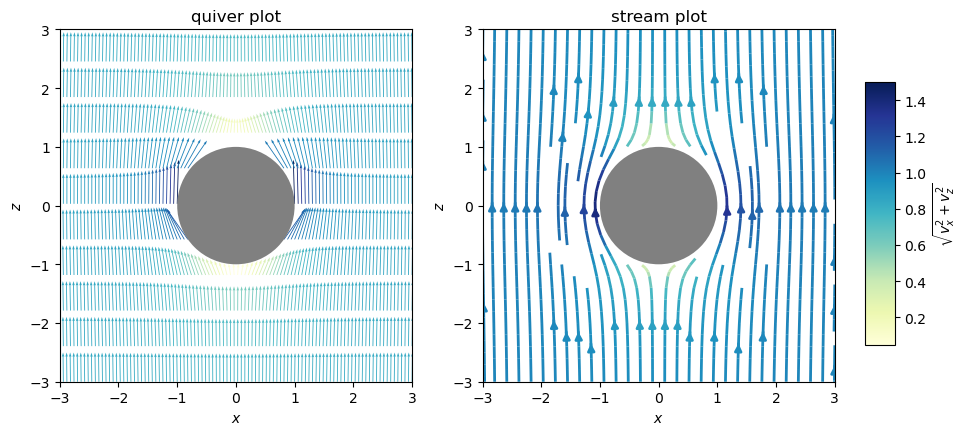

In [44]:
fig, (ax1, ax2) = plt.subplots(1,  2)

ax1.set_xlabel('$x$')
ax1.set_ylabel('$z$')
ax1.set_xlim([-xmax, xmax])
ax1.set_ylim([-zmax, zmax])
ax1.set_title('quiver plot')
ax1.set_aspect('equal')

# plot velocity in the phi=0 plane, skip some points for clarity
skip = 10
ax1.quiver(x[::skip], z[::skip], vx[::skip], vz[::skip],
           np.sqrt(vx[::skip]**2+vz[::skip]**2), cmap='YlGnBu',
           scale_units='xy', scale=2)
# show the sphere
ax1.add_patch(plt.Circle((0, 0), radius=rad, facecolor='gray', zorder=10))

ax2.set_xlabel('$x$')
ax2.set_ylabel('$z$')
ax2.set_xlim([-xmax, xmax])
ax2.set_ylim([-zmax, zmax])
ax2.set_title('stream plot')
ax2.set_aspect('equal')

strm = ax2.streamplot(x, z, vx, vz,
                      color=np.sqrt(vx**2+vz**2),
                      linewidth=2, cmap='YlGnBu')
# show the sphere
ax2.add_patch(plt.Circle((0, 0), radius=rad, facecolor='gray', zorder=10))

# make the colorabar look nice ...
pos = ax2.get_position()
pad, width = 0.03, 0.03
ax3 = fig.add_axes([pos.xmax + pad, pos.ymin + 2*pad,
                  
                   width, 0.7*(pos.ymax-pos.ymin)])
fig.colorbar(strm.lines, cax=ax3, label=r'$\sqrt{v_x^2+v_z^2}$')

fig.set_size_inches(10, 8)

## Streamlines

In [45]:
# define the inviscid streamfunction
# ASSUMING variables etc as in the "VISUALIZATION" section
psi_i = 1/2*velmag*rad**2*((rp/rad)**2 - 1/(rp/rad))*np.sin(th)**2

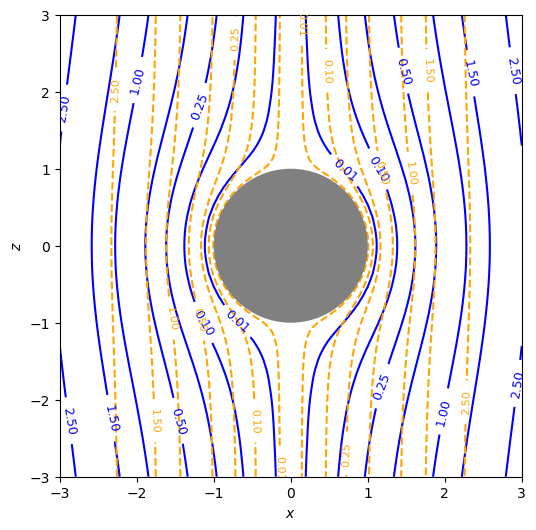

In [46]:
# plot streamlines in the phi=0 plane
fig, ax = plt.subplots()
ax.set_xlabel('$x$')
ax.set_ylabel('$z$')
ax.set_aspect('equal')

# customize contours again
levels = np.array([0.01, 0.1, 0.25, 0.5, 1, 1.5, 2.5])

# plot viscous streamlines
cspsi = ax.contour(x, z, psi_v, levels, colors='b')
# label the contours with their values
ax.clabel(cspsi, inline=True, fontsize=9)

# plot inviscid streamlines
cspsi_i = ax.contour(x, z, psi_i, levels, colors='orange', linestyles='dashed')
# label the contours with their values
ax.clabel(cspsi_i, inline=True, fontsize=8)

# show the sphere
c = plt.Circle((0, 0), radius=rad, facecolor='gray', zorder=10)
ax.add_patch(c)

# make the output figure a bit larger
fig.set_size_inches(8, 6)

Observe that that red (invscid) streamlines are much more closely packed near the surface of the sphere. The sphere only perturbs the $Re\to\infty$ flow nearby.

Meanwhile, in the $Re\to0$ flow (blue streamlines), the sphere causes a much more widespread disturbance in the flow. Interesting.

## Drag force on the sphere in ideal flow?

We proceed as above.

#### The pressure


Now the pressure is given by Bernouilli's equation:
$$
  p(r,\theta) = p_0 + \tfrac{1}{2}\rho |\underline{v}|^2 = p_0 + \tfrac{1}{2}\rho \underline{v}\cdot\underline{v},
$$
since there are no body forces or unsteadiness.

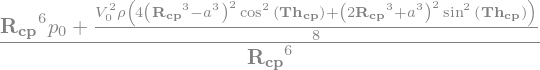

In [47]:
rho = sp.Symbol('rho')
p0 = sp.Symbol('p0')
p_i = p0 + sp.Rational(1, 2)*rho*(vel_i & vel_i)
p_i.simplify()

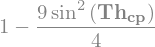

In [48]:
# sanity check: calculate the pressure coefficient, Panton Eq. (19.8.8)
# C_p = (p-pinf)/(1/2 rho V0^2) = (p - pinf)/(p0 - pinf)
pinf = sp.limit(p_i, cp.R, sp.oo)
# on the surface of the sphere, r=a
((p_i-pinf)/(p0-pinf)).subs({cp.R: a}).simplify()

In [49]:
# don't forget the cos from the evaluation of e_r*T*e_z above
p_iint = 2*sp.pi*a**2 \
         * sp.integrate((-p_i.subs({cp.R: a})*sp.cos(cp.Th)) * sp.sin(cp.Th), 
                        (cp.Th, 0, sp.pi))
p_iint.simplify()

#### The viscous stress on the sphere

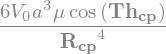

In [50]:
mu = sp.Symbol('mu')
# use dot products (&) with coord vectors to extra v_r, v_th from vel vector computed above
taurr_i = 2*mu*(vel_i & cp.r).diff(cp.R)
taurr_i.simplify()

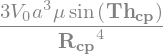

In [51]:
taurth_i = mu*(cp.R*((vel_i & cp.th)/cp.R).diff(cp.R) \
               + (vel_i & cp.r).diff(cp.Th)/cp.R)
taurth_i.simplify()

In [52]:
# don't forget the cos, -sin from the evaluation of e_r*T*e_z above
tau_iint = 2*sp.pi*a**2 \
           * sp.integrate((taurr_i.subs({cp.R: a})*sp.cos(cp.Th)
                           - taurth_i.subs({cp.R: a})*sp.sin(cp.Th)) * sp.sin(cp.Th),
                           (cp.Th, 0, sp.pi))
tau_iint.simplify()

Both the $p$ and $\underline{\underline{\tau}}$ contributions from $\underline{e}_r\cdot\underline{\underline{T}}\cdot\underline{e}_z$ integrate to 0. Ideal flow exerts no drag force (because it is acting as 'inviscid')!

# A PARADOX

For ideal flows, given $\underline{v}$, we can always verify that the viscous forces $\nabla\cdot\underline{\underline{\tau}}=\underline{0}$ from the definition of the viscous stress tensor.

For Stokes flow, could we verify that the inertial forces $\rho\underline{v}\cdot\nabla\underline{v}=\underline{0}$?

SymPy stuggles with spherical coordinates sometimes, so we use the formulas from Table B.2 in Paton's Appendix (noting a typo, corrected below in red, cross-checked against [here](https://en.wikipedia.org/wiki/Del_in_cylindrical_and_spherical_coordinates)):
\begin{align*}
  [\underline{v} \cdot \nabla \underline{v}]_r &= v_r\left(\frac{\partial v_r}{\partial r}\right)+v_\theta\left(\frac{1}{r} \frac{\partial v_r}{\partial \theta}-\frac{v_\theta}{r}\right), \\
  [\underline{v} \cdot \nabla \underline{v}]_\theta &= v_r\left(\frac{\partial v_\theta}{\partial r}\right)+v_\theta\left(\frac{1}{r} \frac{\partial v_\theta}{\partial \theta} \,{\color{red}+}\, \frac{v_r}{r}\right),\\
  [\underline{v} \cdot \nabla \underline{v}]_\phi &= 0.
\end{align*}

In [53]:
velr = (vel & cp.r)
velth = (vel & cp.th)
v_del_v_r = sp.simplify(velr * velr.diff(cp.R) \
                        + velth * (velr.diff(cp.Th) - velth)/cp.R)
v_del_v_th = sp.simplify(velr * velth.diff(cp.R) \
                         + velth * (velth.diff(cp.Th) + velr)/cp.R)

full_v_del_v = (v_del_v_r * cp.r + v_del_v_th * cp.th + 0 * cp.ph)
# v_del_v_z = v_del_v_r * sp.cos(cp.Th) - v_del_v_th * sp.sin(cp.Th)

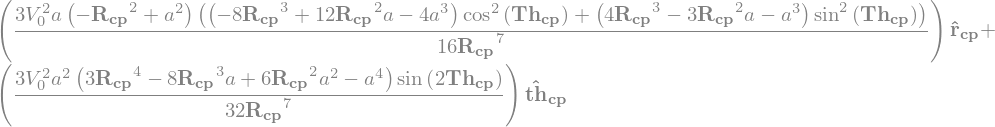

In [54]:
full_v_del_v

Apparently $\underline{v}\cdot\nabla\underline{v} \ne \underline{0}$!

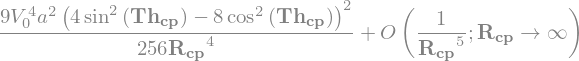

In [55]:
sp.series(full_v_del_v & full_v_del_v, cp.R, sp.oo, 5)

This leads us to re-evaluate the assumption that in Stokes flows inertial forces $\sim|\rho \underline{v}\cdot\nabla\underline{v}|$ are much weaker that viscous forces $\sim|\mu \nabla^2\underline{v}|$. Calculating these terms by hand is very tedious, so we do it with SymPy.

SymPy doesn't make it easy to compute the Laplacian of a vector in non-Cartesian coordinates. But we know that:
$$
    \nabla^2 \underline{v} = - \nabla\times\underline{\omega}.
$$


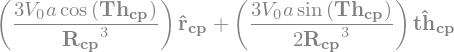

In [56]:
laplacian_v = sp.simplify(-curl(omega))
laplacian_v

These expressions depend on $r$ and $\theta$, let's consider two special cases. 

#### The "near field"

First, $r\to a$, on the surface of the sphere.

$|\rho \underline{v}\cdot\nabla\underline{v}|^2$ as $r\to a$:

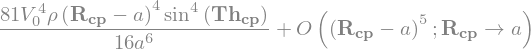

In [57]:
sp.series(rho*(full_v_del_v & full_v_del_v), cp.R, a, 5)

$|\mu \nabla^2\underline{v}|^2$ as $r\to a$: 

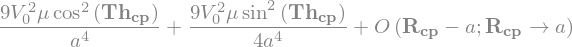

In [58]:
sp.series(mu*(laplacian_v & laplacian_v), cp.R, a, 1)

Thus, the ratio
$$
    \frac{|\rho \underline{v}\cdot\nabla\underline{v}|^2}{|\mu \nabla^2\underline{v}|^2} \sim (r-a)^4 \to 0 ~~~\text{as}~~~ r\to a
$$
looks fine.

#### The "far field"

Second, $r\to\infty$, far away from the sphere in the uniform flow.

$|\rho \underline{v}\cdot\nabla\underline{v}|^2$ as $r\to \infty$:

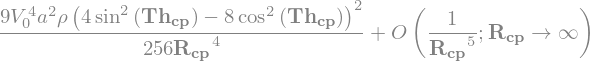

In [59]:
sp.series(rho*(full_v_del_v & full_v_del_v), cp.R, sp.oo, 5)

$|\mu \nabla^2\underline{v}|^2$ as $r\to \infty$: 

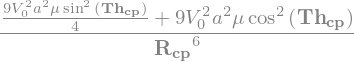

In [60]:
sp.series(mu*(laplacian_v & laplacian_v), cp.R, sp.oo, 7)
# or take it along theta = \pi/4 transect to make it cleaner

Thus, ratio
$$
    \frac{|\rho \underline{v}\cdot\nabla\underline{v}|^2}{|\mu \nabla^2\underline{v}|^2} \sim \frac{1/r^4}{1/r^6} = r^2 ~~~\text{as}~~~ r\to\infty
$$
is unbounded!?

So, this Reynolds number estimated from the actual solution is growing with $r$ as $r\to\infty$, showing that the $Re=0$ assumption is wrong very far away from the sphere. Oops!

[Oseen resolved this inconsistency](http://brennen.caltech.edu/fluidbook/basicfluiddynamics/Stokesflow/oseenflow.pdf) in Stokes' solution for low-$Re$ flow past a sphere.

##### $\underline{v}\cdot\nabla\underline{v}$ _without_ using the appendix of Panton?

We could also compute the material derivative using an identity we've seen before:
$$
    (\underline{v} \cdot \nabla) \underline{v} = \frac{1}{2} \nabla(\underline{v} \cdot \underline{v})  - \underline{v} \times (\nabla \times \underline{v}),
$$
in which all terms are defined without needing to take gradients of vectors.

In [61]:
v_del_v = sp.Rational(1, 2)*gradient(vel & vel) - (vel ^ curl(vel))
v_del_v = v_del_v.simplify()

In [62]:
v_del_v & cp.r == v_del_v_r

False

In [63]:
v_del_v & cp.th == v_del_v_th

True

Well, that's odd! Maybe another Sympy bug...